# RAG

## Data connection

먼저 ‘Data connection’에 대해 설명하자면, Data connection은 LLM과 외부의 데이터를 연결하기 위한 기능이다.

대형 언어 모델(LLM)은 사전에 학습된 데이터만을 기반으로 답변을 생성합니다.<br />
따라서 모델이 학습을 마친 시점 이후의 최신 정보나, 기업 내부 문서와 같은 비공개·사적 데이터에 대해서는 알지 못한다는 한계가 있습니다.<br />
만약 모델이 모르는 정보에 대해 질문을 던진다면, 모른다고 답변하거나 심한 경우 그럴싸하지만 완전히 거짓인 답변을 만들어내는 할루시네이션(Hallucination, 환각 현상)이 발생하게 됩니다.<br />
이러한 문제를 해결하기 위해 등장한 개념이 바로 프롬프트에 외부 참고 자료(Context)를 함께 넣어주는 RAG(검색 증강 생성)이며, 이 과정에서 외부 데이터를 LLM이 이해할 수 있도록 연결해 주는 핵심 기술이 Data Connection입니다.

In [ ]:
GPT 프롬프트에서 질문하기
아래 두 문장을 각각 프롬프트로 물어 보기

In [ ]:
LangChain이란?

In [ ]:
랭체인의 README (https://github.com/langchain-ai/langchain/blob/master/README.md)의 내용을 컨텍스트(context)에 포함시켜 질문해 보겠다.

In [ ]:
문맥을 고려하여 한 문장으로 질문에 답해 주세요.

문맥: """
<랭체인의 README 내용>
"""

질문: LangChain이란 무엇인가요?

문맥을 마탕으로 대답을 하는 것을 알 수 있다.<br />
이렇게 질문과 관련된 문서의 내용을 컨텍스트에 포함시킴으로써 LLM이 본래 알지 못하는 것을 답변하게 할 수 있다.<br />
단, LLM은 토큰 수에 제한이 있기 때문에 모든 데이터를 컨텍스트에 담을 수는 없다.<br />
입력과 관련이 있을 것 같은 문서를 검색하여 컨텍스트에 포함시키는 방법이 있다<br />
문서를 Embeddings API 등으로 벡터화해 입력과 벡터가 가까운 문서를 검색하여 컨텍스트에 포함시키는 기법을 RAG(Retrieval Augmented Generation)¹라고 한다.<br />
문서는 미리 준비된 데이터베이스에서 검색할 수도 있고, 구글과 같은 검색엔진으로 웹상에서 검색할 수도 있다<br />

랭체인의 Data connection에서는 특히 벡터 스토어(Vector store)를 사용하여 문서를 벡터화하여 저장해 두었다가 입력된 텍스트와 벡터에 가까운 문서를 검색하여 컨텍스트에 포함시켜 사용하는 방법을 제공한다.<br />
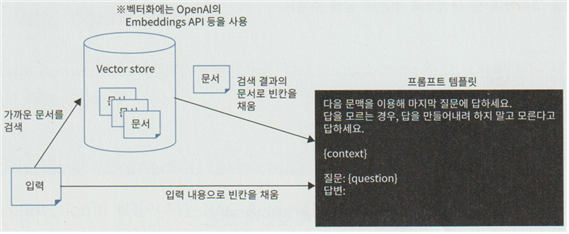

### Data connection 개요
RAG에 사용할 수 있는 랭체인의 모듈은 ‘Data connection’이다. <br />
* Document loaders: 데이터 소스로부터 문서를 불러온다. <br />
* Document transformers: 문서에 어떤 종류의 변환을 가한다. <br />
* Text embedding models: 문서를 벡터화한다. <br />
* Vector stores: 벡터화된 문서를 저장할 수 있는 저장소 <br />
* Retrievers: 입력한 텍스트와 관련된 문서를 검색한다. <br />
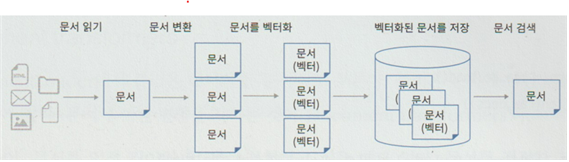

### 1. Document loaders
데이터 로딩에 사용하는 것이 ‘Document loaders’다.

In [9]:
# 여기서는 깃허브 저장소에 공개된 문서를 불러오기로 한다. 먼저 GitPython이라는 패키지가 필요하므로 설치한다.
!pip install langchain-community GitPython==3.1.36

  Attempting uninstall: GitPython
    Found existing installation: GitPython 3.1.50
    Uninstalling GitPython-3.1.50:
      Successfully uninstalled GitPython-3.1.50


In [10]:
# !pip install langchain-community GitPython

# 임포트 경로를 langchain_community로 수정합니다.
from langchain_community.document_loaders import GitLoader

def file_filter(file_path):
    return file_path.endswith(".md")  # 어떤 파일만 읽을 것인지 결정하는 함수

loader = GitLoader(
    clone_url="https://github.com/langchain-ai/langchain",
    repo_path="./langchain", # 다운로드 저장소를 어디에 저장할지 지정
    branch="master", # Git의 어느 브랜치를 사용할지 지정
    file_filter=file_filter,
)

raw_docs = loader.load()
print(f"가져온 마크다운 문서 개수: {len(raw_docs)}")

가져온 마크다운 문서 개수: 29


표) 랭체인의 DocumentLoader (일부)<br />
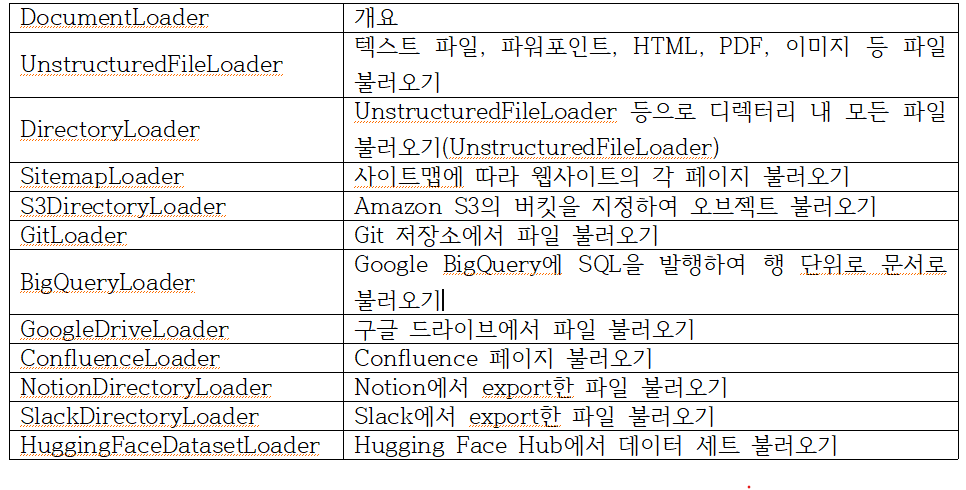

## 인터넷(깃허브)에 있는 거대한 코드 저장소를 AI가 읽을 수 있는 책(Document 객체) 형태로 내 컴퓨터에 자동 다운로드 및 변환해 주는 아주 강력한 수집 예제

In [12]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from langchain_community.document_loaders import GitLoader

# 1. 파일 필터 함수 정의
# 저장소 안에서 확장자가 '.py'인 파이썬 코드 파일만 골라내도록 설정합니다.
def python_file_filter(file_path):
    return file_path.endswith(".py")

# 2. GitLoader 객체 생성
# clone_url의 저장소를 로컬의 repo_path 경로로 복사(Clone)해 옵니다.
loader = GitLoader(
    clone_url="https://github.com/langchain-ai/langchain", # 복사할 깃허브 주소
    repo_path="./langchain_repo",                         # 로컬에 저장될 폴더 경로
    branch="master",                                      # 가져올 브랜치 이름
    file_filter=python_file_filter                        # 위에서 만든 필터 함수 적용
)

print("깃허브에서 저장소를 다운로드(Clone) 중입니다... 잠시만 기다려 주세요.")

# 3. 데이터 로드 실행
# 로드가 완료되면 각 파일의 내용이 'Document' 객체 리스트로 담깁니다.
documents = loader.load()

print("다운로드 및 로드가 완료되었습니다!")
print(f"가져온 파이썬 파일 총 개수: {len(documents)}개\n")

# =====================================================================
# 4. 가져온 문서 구조 뜯어보기 (첫 번째 파일 샘플 확인)
# =====================================================================
if documents:
    first_doc = documents[0]
    
    print("==================================================")
    print("📄 [첫 번째 파일 메타데이터 정보]")
    print("==================================================")
    # metadata 안에는 파일 경로, 파일 이름, 소스 타입 등이 딕셔너리로 들어있습니다.
    print(f"파일 경로: {first_doc.metadata.get('file_path')}")
    print(f"파일 이름: {first_doc.metadata.get('file_name')}")
    
    print("\n==================================================")
    print("[첫 번째 파일 실제 내용 (앞부분 300자)]")
    print("==================================================")
    # page_content에 코드 내용 전체가 문자열(String)로 들어있습니다.
    print(first_doc.page_content[:300])
else:
    print("조건에 맞는 파일이 존재하지 않습니다.")

깃허브에서 저장소를 다운로드(Clone) 중입니다... 잠시만 기다려 주세요.
다운로드 및 로드가 완료되었습니다!
가져온 파이썬 파일 총 개수: 2531개

📄 [첫 번째 파일 메타데이터 정보]
파일 경로: .github\scripts\check_diff.py
파일 이름: check_diff.py

[첫 번째 파일 실제 내용 (앞부분 300자)]
"""Analyze git diffs to determine which directories need to be tested.

Intelligently determines which LangChain packages and directories need to be tested,
linted, or built based on the changes. Handles dependency relationships between
packages, maps file changes to appropriate CI job configuration


### 2. Document transformers

DocumentLoader에서 불러온 데이터를 ‘문서’라고 부른다.<br />
불러온 문서에 어떤 변환을 가하는 경우가 많다.<br /> 
문서에 어떤 변환을 가하는 것이 ‘Document transformers’다.<br />

예를 들어, 문서를 일정 길이의 청크(문단)로 분할하고 싶을 때가 있다.<br />
문서를 적절한 크기의 청크로 분할하면 LLM에 입력하는 토큰 수를 줄이고 더 정확한 답변을 얻을 수 있다.<br /> 
랭체인의 CharacterTextSplitter 클래스를 사용해 문서를 청크로 분할하는 예는 다음과 같다.

In [13]:
from langchain_text_splitters import CharacterTextSplitter

# 텍스트 분할기 설정 (1000자 단위로 자르고, 겹치는 부분은 0자로 설정)
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)

# 이전 단계에서 가져온 raw_docs 분할하기
docs = text_splitter.split_documents(raw_docs)
print(len(docs))

Created a chunk of size 1455, which is longer than the specified 1000


122


원래 29개였던 문서가 122개로 분할됐다.

앞의 예시에서는 글자 수로 청크를 나누었다. 이 외에도 tiktoken에서 측정한 토큰 수로 분할하거나 파이썬 등의 소스 코드를 가능한 한 클래스나 함수처럼 묶어서 분할하는 기능도 제공된다.


GitLoader를 이용해 파이썬이나 자바스크립트 같은 '소스코드'를 분석할 경우, 단순 글자 수로 뚝뚝 자르는 CharacterTextSplitter보다는 코드의 문법 구조(함수 단위, 클래스 단위)를 인식해서 예쁘게 잘라주는 RecursiveCharacterTextSplitter.from_language를 사용하는 것이 훨씬 좋습니다.

In [14]:
# 1. 필요한 모듈 임포트 (최신 표준 경로 적용)
from langchain_community.document_loaders import GitLoader
from langchain_text_splitters import CharacterTextSplitter

# 2. 마크다운(.md) 파일만 골라내는 필터 함수
def file_filter(file_path):
    return file_path.endswith(".md")

# 3. [1단계: Loader] 깃허브에서 저장소 통째로 가져오기
loader = GitLoader(
    clone_url="https://github.com/langchain-ai/langchain",
    repo_path="./langchain",
    branch="master",
    file_filter=file_filter,
)

print(" 깃허브에서 마크다운 파일을 수집하는 중입니다...")
raw_docs = loader.load()
print(f" 수집된 원본 마크다운 문서 개수: {len(raw_docs)}개")
print("--------------------------------------------------")

# 4. [2단계: Splitter] 수집된 문서를 1000자 단위로 쪼개기
# 기본적으로 CharacterTextSplitter는 줄바꿈("\n\n")을 기준으로 작동하려 합니다.
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)

print(" 수집된 원본 문서들을 잘게 쪼개는 중(Splitting)입니다...")
docs = text_splitter.split_documents(raw_docs)

# 5. 최종 결과 확인
print(f" 쪼개진 후 생성된 총 조각(Chunk) 개수: {len(docs)}개")

 깃허브에서 마크다운 파일을 수집하는 중입니다...


Created a chunk of size 1455, which is longer than the specified 1000


 수집된 원본 마크다운 문서 개수: 29개
--------------------------------------------------
 수집된 원본 문서들을 잘게 쪼개는 중(Splitting)입니다...
 쪼개진 후 생성된 총 조각(Chunk) 개수: 122개


이 코드가 실행되면 내부 데이터는 아래와 같은 구조로 변하게 됩니다.

1. raw_docs 단계 (리스트 길이 예: 5개)
깃허브에서 가져온 5개의 마크다운 파일 내용이 통째로 들어가 있습니다.<br /> 파일 하나당 글자 수가 5,000자든 10,000자든 파일 1개당 Document 객체 1개로 매핑됩니다.
2. docs 단계 (리스트 길이 예: 35개)
text_splitter를 통과하면서 너무 길었던 원본 파일들이 지정하신 chunk_size=1000(약 1000글자) 크기로 동강이 납니다.<br /> 그 결과 원본 파일은 5개였지만, 잘게 쪼개진 조각(Chunk)은 35개로 불어나게 됩니다.

표) 랭체인의 DocumentTransformer (일부)<br />
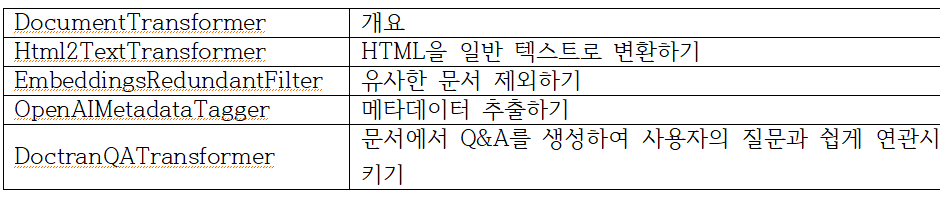

### 3.Text embedding models

In [ ]:
문서 변환 처리를 마쳤다면 텍스트를 벡터화할 차례다.<br />
재미나이의 Embeddings API를 사용하여 `gemini-embedding-001`라는 모델로 텍스트를 벡터화한다. <br />   

LangChain에는 재마나이의 Embeddings API를 래핑한 `GoogleGenerativeAIEmbeddings`라는 클래스가 있다.<br /> `GoogleGenerativeAIEmbeddings`도 마찬가지로 텍스트 벡터화에 사용할 수 있는 것이 ‘Text embedding models’다

In [16]:
import os
# 1. API 키 설정 (보안을 위해 사용 후 노출되지 않도록 주의하세요!)
os.environ["GOOGLE_API_KEY"] = "your_api_key"

# 2. 가장 최신의 공식 권장 클래스 임포트
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# 3. 임베딩 모델 선언
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
# 또는 최신 프리뷰 모델을 원하시면 아래 모델을 사용하셔도 됩니다.
# embeddings =
# GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview")

문서의 벡터화 처리는 다음에 설명할 Vector store 클래스에 데이터를 저장할 때 내부적으로 수행된다.<br />
그러나 이러한 설명만으로는 벡터화의 구체적인 과정을 상상하기 어려울 수 있으므로, 여기서 벡터화를 직접 시도해 보겠다.

In [ ]:
이후의 코드를 실행하려면 `tiktoken`이라는 패키지가 필요하므로 다음과 같이 `tiktoken`을 설치한다.⁷

In [17]:
!pip install tiktoken==0.6.0

   ---------------------------------------- 0.0/798.7 kB ? eta -:--:--
   ---------------------------------------- 798.7/798.7 kB 11.4 MB/s  0:00:00


In [18]:
query = "AWS S3에서 데이터를 불러올 수 있는 DocumentLoader가 있나요?"

# 3. 임베딩 벡터 생성
vector = embeddings.embed_query(query)
print("벡터 차원 크기:", len(vector))
print("벡터 데이터 일부:", vector[:5])

벡터 차원 크기: 3072
벡터 데이터 일부: [0.026992848, 0.015734974, 0.01939729, -0.06874713, -0.012229344]


'AWS S3에서 데이터를 불러올 수 있는 DocumentLoader가 있나요?'라는 문자열이 3072차원의 벡터(숫자 목록)로 변환되었다.

### 반드시 GitLoader -> CharacterTextSplitter -> GoogleGenerativeAIEmbeddings 순서로 진행해야 합니다.
<br /><br />
데이터는 단계별로 형태가 완전히 변하기 때문에, 앞 단계의 결과물이 있어야만 다음 단계가 작동할 수 있습니다.<br />
1. GitLoader (재료 수집): 인터넷(깃허브)에 있는 원격 코드나 마크다운 파일을 내 컴퓨터 메모리로 가져와 하나의 긴 텍스트 묶음(Document 객체)으로 만듭니다.
(아직은 가공되지 않은 통째로의 서류철입니다.)<br />
2. CharacterTextSplitter (크기 조절): 너무 길어서 AI 모델이 한 번에 읽지 못하는 원본 서류철을 1,000자나 500자 같이 AI가 소화하기 좋은 적당한 크기의 조각(Chunk)으로 싹둑싹둑 자릅니다.<br />
3. GoogleGenerativeAIEmbeddings (수학적 가공): 잘게 쪼개진 글자(텍스트) 조각들을 컴퓨터가 이해하고 검색할 수 있는 수학적 숫자 좌표(벡터)로 변환합니다.

In [21]:
!pip install -qU langchain-community langchain-text-splitters langchain-google-genai GitPython

In [24]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from langchain_community.document_loaders import GitLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# 구글 API 키 설정 (본인의 API 키를 입력하거나 .env 파일을 사용하세요)
# os.environ["GOOGLE_API_KEY"] = "your-gemini-api-key-here"

# ---------------------------------------------------------------------
# 단계 1: GitLoader (재료 수집)
# ---------------------------------------------------------------------
print("단계 1️: GitLoader를 사용해 깃허브에서 마크다운 문서를 다운로드하는 중...")

def markdown_filter(file_path):
    return file_path.endswith(".md")

loader = GitLoader(
    clone_url="https://github.com/langchain-ai/langchain",
    repo_path="./langchain_data",
    branch="master",
    file_filter=markdown_filter,
)
raw_documents = loader.load()
print(f" [수집 완료] 원본 마크다운 파일 개수: {len(raw_documents)}개")
print("-" * 50)


# ---------------------------------------------------------------------
# 단계 2: CharacterTextSplitter (크기 조절)
# ---------------------------------------------------------------------
print("단계 2️: CharacterTextSplitter를 사용해 긴 문서를 1000자 단위로 쪼개는 중...")

# 1000자 단위로 자르되, 의미가 끊어지지 않도록 앞뒤로 100자씩 겹치게(Overlap) 설정합니다.
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
split_documents = text_splitter.split_documents(raw_documents)

print(f" [가공 완료] 쪼개진 후 생성된 총 텍스트 조각(Chunk) 개수: {len(split_documents)}개")
print("-" * 50)


# ---------------------------------------------------------------------
# 단계 3: GoogleGenerativeAIEmbeddings (수학적 가공)
# ---------------------------------------------------------------------
print("단계 3️: GoogleGenerativeAIEmbeddings를 사용해 텍스트 조각을 숫자(벡터)로 변환하는 중...")

# 구글의 최신 텍스트 임베딩 모델을 호출합니다.
embeddings_model = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

# 테스트를 위해 전체 중 첫 번째 조각 1개만 골라서 숫자로 변환해봅니다.
sample_text = split_documents[0].page_content

# embed_query 함수를 사용하면 텍스트가 수많은 소수점 숫자가 담긴 리스트(벡터)로 변환됩니다.
vector_result = embeddings_model.embed_query(sample_text)

print(" [변환 완료] 첫 번째 텍스트 조각이 성공적으로 컴퓨터가 이해하는 숫자로 바뀌었습니다!")
print(f" 첫 번째 텍스트 조각의 글자 수: {len(sample_text)}자")
print(f" 변환된 숫자(벡터)의 차원 크기: {len(vector_result)}차원")
print(f" 변환된 숫자 일부 샘플 (앞 5개): {vector_result[:5]}")

단계 1️: GitLoader를 사용해 깃허브에서 마크다운 문서를 다운로드하는 중...


Created a chunk of size 1455, which is longer than the specified 1000


 [수집 완료] 원본 마크다운 파일 개수: 29개
--------------------------------------------------
단계 2️: CharacterTextSplitter를 사용해 긴 문서를 1000자 단위로 쪼개는 중...
 [가공 완료] 쪼개진 후 생성된 총 텍스트 조각(Chunk) 개수: 124개
--------------------------------------------------
단계 3️: GoogleGenerativeAIEmbeddings를 사용해 텍스트 조각을 숫자(벡터)로 변환하는 중...
 [변환 완료] 첫 번째 텍스트 조각이 성공적으로 컴퓨터가 이해하는 숫자로 바뀌었습니다!
 첫 번째 텍스트 조각의 글자 수: 312자
 변환된 숫자(벡터)의 차원 크기: 3072차원
 변환된 숫자 일부 샘플 (앞 5개): [-0.011593239, 0.017252676, 0.00092127087, -0.056006674, -0.020663999]


### 4. Vector stores

저장할 Vector store를 준비하여 문서를 벡터화하여 저장한다. 이 장에서는 크로마(Chroma)라는, 로컬에서 사용 가능한 벡터 스토어를 사용한다. <br />
먼저 크로마를 사용하기 위해 필요한 패키지를 설치한다.

In [1]:
!pip install  chromadb
!pip install  langchain-chroma

   ---------------------------------------- 0.0/525.5 kB ? eta -:--:--
   ---------------------------------------- 525.5/525.5 kB 17.6 MB/s  0:00:00
   ---------------------------------------- 0.0/3.9 MB ? eta -:--:--
   ---------------------------------------- 3.9/3.9 MB 33.3 MB/s  0:00:00

   ----------------------------------------  0/12 [wrapt]
   --- ------------------------------------  1/12 [pulsar-client]
   --- ------------------------------------  1/12 [pulsar-client]
   --- ------------------------------------  1/12 [pulsar-client]
   ------------- --------------------------  4/12 [backoff]
   ---------------- -----------------------  5/12 [asgiref]
   -------------------- -------------------  6/12 [posthog]
   -------------------- -------------------  6/12 [posthog]
   -------------------- -------------------  6/12 [posthog]
   -------------------- -------------------  6/12 [posthog]
   -------------------- -------------------  6/12 [posthog]
   -------------------- -------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-chroma 1.1.0 requires chromadb<2.0.0,>=1.3.5, but you have chromadb 0.4.24 which is incompatible.


In [ ]:
청크로 분할한 문서와 Text embedding model을 기반으로 벡터 스토어를 초기화한다.

In [ ]:
from langchain_chroma import Chroma

db = Chroma.from_documents(
    documents=split_documents,
    embedding=embeddings_model
)

랭체인에서는 크로마 외에도 Faiss, Elasticsearch, Redis 등 벡터 스토어로 사용할 수 있게 제공된다.

한편 Vector stores는 반드시 Embeddings 바로 뒤에 이어서 사용햐야 합니다.<br />
두 단계는 바늘과 실처럼 완전히 하나로 묶여 있는 세트 공정입니다.<br />  

### 5. Retrievers

벡터 스토어에서는 사용자의 입력과 관련된 문서를 가져오는 작업을 수행한다.<br />
랭체인에서 텍스트와 관련된 문서를 가져오는 인터페이스를 ‘Retriever’라고 한다.

벡터 스토어의 인스턴스에서 Retriever를 생성한다.<br />
retriever = db.as_retriever()

Retriever를 사용하여 ‘AWS S3에서 데이터를 불러오는 DocumentLoader가 있나요?’라는 질문과 유사한 문서를 검색해 본다.

In [ ]:
query = "AWS S3에서 데이터를 불러올 수 있는 DocumentLoader가 있나요?"
context_docs = retriever.invoke(query)
print(f"len = {len(context_docs)}")

first_doc = context_docs[0]
print(f"metadata = {first_doc.metadata}")
print(first_doc.page_content)

전체 코드

In [4]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from langchain_community.document_loaders import GitLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma

# --------------------------------------------------
# 1. GitHub 문서 읽기
# --------------------------------------------------
print("1단계 : GitHub 문서 다운로드")

def markdown_filter(file_path):
    return file_path.endswith(".md")

loader = GitLoader(
    clone_url="https://github.com/langchain-ai/langchain",
    repo_path="./langchain_data",
    branch="master",
    file_filter=markdown_filter,
)

raw_documents = loader.load()

print(f"원본 문서 : {len(raw_documents)}개")

# ★ 무료 API를 위해 문서 개수 제한
raw_documents = raw_documents[:10]

print(f"실습에 사용할 문서 : {len(raw_documents)}개")
print("-" * 50)


# --------------------------------------------------
# 2. 문서 분할
# --------------------------------------------------
print("2단계 : 문서 분할")

text_splitter = CharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

split_documents = text_splitter.split_documents(raw_documents)

# ★ Chunk도 제한
split_documents = split_documents[:100]

print(f"Chunk 개수 : {len(split_documents)}개")
print("-" * 50)


# --------------------------------------------------
# 3. 임베딩 모델
# --------------------------------------------------
print("3단계 : Gemini Embedding 모델 준비")

embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)

print("모델 준비 완료")
print("-" * 50)


# --------------------------------------------------
# 4. Chroma 저장
# --------------------------------------------------
print("4단계 : Chroma 저장")

vectorstore = Chroma.from_documents(
    documents=split_documents,
    embedding=embeddings
)

print("벡터 저장 완료")
print("-" * 50)


# --------------------------------------------------
# 5. Retriever 생성
# --------------------------------------------------
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 1}
)

query = "How to install LangChain?"

print(f"질문 : {query}")

docs = retriever.invoke(query)

print("-" * 50)

if docs:
    print("검색 성공")
    print("파일 :", docs[0].metadata.get("file_path"))
    print()
    print(docs[0].page_content[:500])
else:
    print("검색 결과가 없습니다.")

1단계 : GitHub 문서 다운로드


Created a chunk of size 1455, which is longer than the specified 1000


원본 문서 : 29개
실습에 사용할 문서 : 10개
--------------------------------------------------
2단계 : 문서 분할
Chunk 개수 : 70개
--------------------------------------------------
3단계 : Gemini Embedding 모델 준비
모델 준비 완료
--------------------------------------------------
4단계 : Chroma 저장
벡터 저장 완료
--------------------------------------------------
질문 : How to install LangChain?
--------------------------------------------------
검색 성공
파일 : libs\langchain_v1\README.md

## Quick Install

```bash
uv add langchain
```

## 🤔 What is this?

LangChain is the easiest way to start building agents and applications powered by LLMs. With under 10 lines of code, you can connect to OpenAI, Anthropic, Google, and [more](https://docs.langchain.com/oss/python/integrations/providers/overview). LangChain provides a pre-built agent architecture and model integrations to help you get started quickly and seamlessly incorporate LLMs into your agents and applications.

We recommend 


In [ ]:
###  6. RetrievalQA(create_retrieval_chain)

검색한 내용을 PromptTemplate에 context(문맥)로 삽입하여 LLM에게 질문하고 답변(QA)을 요청하는 경우가 있습니다.<br />
LangChain에서는 이 두 가지 과정(문서 검색 + LLM 답변 생성)을 수동으로 일일이 코딩하지 않고, 하나의 거대한 체인으로 묶어서 자동화해 주는 표준 함수인 create_retrieval_chain을 제공한다.<br />
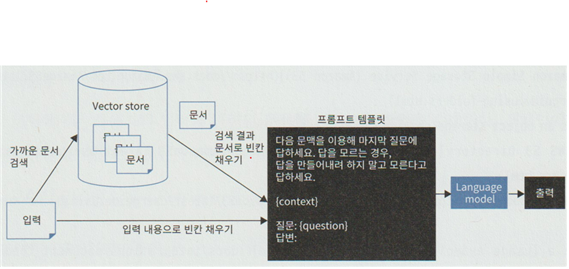

### RAG의 전체 단계
GitHub 문서 -> GitLoader -> CharacterTextSplitter -> GoogleGenerativeAIEmbeddings -> Vector Store (Chroma) -> Retriever -> ChatGoogleGenerativeAI -> ChatPromptTemplate -> create_stuff_documents_chain() -> create_retrieval_chain() -> invoke() -> 최종 답변 생성

### RAG 데이터 연결의 최종 완전체 10단계

1. GitLoader : 원본 문서들을 인터넷(GitHub)에서 복사해 옵니다.
2. CharacterTextSplitter : 긴 문서를 다루기 좋은 크기의 텍스트 조각(Chunk)으로 나눕니다.
3. GoogleGenerativeAIEmbeddings : 쪼개진 텍스트 조각들을 컴퓨터가 이해할 수 있는 숫자 좌표(Vector)로 변환합니다.
4. Vector Store (Chroma) : 변환된 숫자 좌표들을 검색하기 좋게 벡터 데이터베이스(Vector Store)에 저장합니다.
5. Retriever : 사용자가 질문을 던졌을 때, 벡터 데이터베이스에서 질문과 의미적으로 가장 관련성이 높은 문서 조각(Chunk)만 빠르게 찾아 가져옵니다.
6. ChatGoogleGenerativeAI (LLM) : 질문에 대한 답변을 생성할 대규모 언어 모델(LLM)을 준비합니다.
7. ChatPromptTemplate : 검색된 문서(Context)와 사용자의 질문(Question)을 하나의 프롬프트(Prompt)로 구성하여 LLM이 이해하기 쉬운 형태로 만듭니다.
8. create_stuff_documents_chain() : 검색된 여러 문서 조각을 하나의 Context로 묶어 LLM에게 전달하는 Document Chain을 생성합니다.
9. create_retrieval_chain() : Retriever와 Document Chain을 연결하여 검색(Retrieval) 과 답변 생성(Generation) 을 하나의 RAG 파이프라인으로 구성합니다.
10. invoke() : 사용자의 질문을 RAG 파이프라인에 전달하여 최종 답변을 생성하고, 필요하면 답변 생성에 사용된 참고 문서(Context)도 함께 확인합니다.

In [16]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from langchain_community.document_loaders import GitLoader
from langchain_text_splitters import CharacterTextSplitter

from langchain_google_genai import (
    GoogleGenerativeAIEmbeddings,
    ChatGoogleGenerativeAI,
)

from langchain_chroma import Chroma

from langchain_core.prompts import ChatPromptTemplate

# LangChain 1.x에서는 classic 사용
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import (
    create_stuff_documents_chain,
)

####################################################
# 1. GitHub 문서 다운로드
####################################################

print("="*60)
print("1. GitHub 문서 다운로드")
print("="*60)

def markdown_filter(path):
    return path.endswith(".md")

loader = GitLoader(
    clone_url="https://github.com/langchain-ai/langchain",
    repo_path="./langchain_data",
    branch="master",
    file_filter=markdown_filter,
)

raw_documents = loader.load()

print("원본 문서 :", len(raw_documents))

# 무료 API를 위해 일부만 사용
raw_documents = raw_documents[:10]

print("사용 문서 :", len(raw_documents))

####################################################
# 2. 문서 분할
####################################################

print("\n"+"="*60)
print("2. Text Split")
print("="*60)

text_splitter = CharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
)

documents = text_splitter.split_documents(raw_documents)

documents = documents[:100]

print("Chunk :", len(documents))

####################################################
# 3. Embedding
####################################################

print("\n"+"="*60)
print("3. Embedding")
print("="*60)

embedding = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

####################################################
# 4. Vector Store
####################################################

print("\n"+"="*60)
print("4. Chroma")
print("="*60)

vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding,
)

####################################################
# 5. Retriever
####################################################

print("\n"+"="*60)
print("5. Retriever")
print("="*60)

retriever = vectorstore.as_retriever(
    search_kwargs={
        "k":3
    }
)

####################################################
# 6. LLM
####################################################

print("\n"+"="*60)
print("6. Gemini")
print("="*60)

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)

####################################################
# 7. Prompt
####################################################

print("\n"+"="*60)
print("7. Prompt")
print("="*60)

prompt = ChatPromptTemplate.from_template(
"""
You are a helpful AI assistant.

Use ONLY the following context.

Context:
{context}

Question:
{input}

Answer:
"""
)

####################################################
# 8. Document Chain
####################################################

print("\n"+"="*60)
print("8. Document Chain")
print("="*60)

document_chain = create_stuff_documents_chain(
    llm=llm,
    prompt=prompt,
)

####################################################
# 9. Retrieval Chain
####################################################

print("\n"+"="*60)
print("9. Retrieval Chain")
print("="*60)

retrieval_chain = create_retrieval_chain(
    retriever,
    document_chain,
)

####################################################
# 10. 질문
####################################################

query = "How do I install LangChain?"

print("\n질문")
print(query)

response = retrieval_chain.invoke(
    {
        "input": query
    }
)

####################################################
# 11. 답변
####################################################

print("\n")
print("="*60)
print("답변")
print("="*60)

print(response["answer"])

####################################################
# 12. 검색된 문서
####################################################

print("\n")
print("="*60)
print("검색된 문서")
print("="*60)

for i, doc in enumerate(response["context"], start=1):

    print(f"\n[{i}]")

    print(doc.metadata.get("file_path"))

    print("-"*40)

    print(doc.page_content[:300])

1. GitHub 문서 다운로드


Created a chunk of size 1455, which is longer than the specified 1000


원본 문서 : 29
사용 문서 : 10

2. Text Split
Chunk : 70

3. Embedding

4. Chroma

5. Retriever

6. Gemini

7. Prompt

8. Document Chain

9. Retrieval Chain

질문
How do I install LangChain?


답변
To install LangChain, use the following command:

```bash
uv add langchain
```


검색된 문서

[1]
libs\langchain_v1\README.md
----------------------------------------
## Quick Install

```bash
uv add langchain
```

## 🤔 What is this?

LangChain is the easiest way to start building agents and applications powered by LLMs. With under 10 lines of code, you can connect to OpenAI, Anthropic, Google, and [more](https://docs.langchain.com/oss/python/integrations/provide

[2]
libs\langchain_v1\README.md
----------------------------------------
## Quick Install

```bash
uv add langchain
```

## 🤔 What is this?

LangChain is the easiest way to start building agents and applications powered by LLMs. With under 10 lines of code, you can connect to OpenAI, Anthropic, Google, and [more](https://docs.langchain.com/oss/pytho

In [ ]:
# pdf관련된 라이브러리 설치

In [ ]:
%pip install PyMuPDF pypdf langchain langchain-community

In [ ]:
####################################################
# 1. pdf파일을 불러오기.
####################################################
# PDF 파일을 읽어서 텍스트 데이터를 추출합니다.
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader('OneNYC_2050_Strategic_Plan.pdf')
data_nyc = loader.load()
print(data_nyc)

loader_seoul = PyPDFLoader('2040_seoul_plan.pdf')
data_seoul = loader_seoul.load()
print(data_seoul)
####################################################
# 2. 문서 분할
####################################################
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
all_splits = text_splitter.split_documents(data_nyc)
for i, split in enumerate(all_splits):
    print(f"Split {i+1}:------------------------------------\n")
    print(split)

seoul_splits = text_splitter.split_documents(data_seoul)
for i, split in enumerate(seoul_splits):
    print(f"Split {i+1}:------------------------------------\n")
    print(split)

### 두개의 문서를 합친다.
print(len(all_splits))
all_splits.extend(seoul_splits)
print(len(all_splits))


####################################################
# 3. Embedding
####################################################
# !pip install langchain-huggingface sentence-transformers
from langchain_huggingface import HuggingFaceEmbeddings
model_name = "BAAI/bge-small-en-v1.5"
encode_kwargs = {'normalize_embeddings': True}

embedding = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={'device': 'cpu'}, # GPU가 있다면 'cuda'로 변경
    encode_kwargs=encode_kwargs
)

####################################################
# 4. Vector Store
####################################################
from langchain_chroma import Chroma

persist_directory = './chroma_store'	 # 크로마 DB를 사용하기 위한 디렉터리 지정. sqllite3파일이 저장됨

# 저장된 크로마 DB가 없다면 새로 만들기
if not os.path.exists(persist_directory): # 디렉터리가 있는지 확인하고 없으면 생성
    print("Creating new Chroma store")
    vectorstore = Chroma.from_documents(
        documents=all_splits,
        embedding=embedding,
        persist_directory=persist_directory
    )
else:
    print("Loading existing Chroma store")
    vectorstore = Chroma(
        persist_directory=persist_directory, 
        embedding_function=embedding
    )

####################################################
# 5. Retriever
####################################################
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
docs = retriever.invoke("서울시의 환경 정책에 대해 궁금해") # 
print(docs)
####################################################
# 6. LLM
####################################################
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.7
)
####################################################
# 7. Prompt
####################################################
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
"""
You are a helpful AI assistant.

Use ONLY the following context.

Context:
{context}

Question:
{input}

Answer:
"""
)

####################################################
# 8. Document Chain
####################################################
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

document_chain = create_stuff_documents_chain(
    llm=llm,
    prompt=prompt,
)

####################################################
# 9. Retrieval Chain
####################################################
from langchain_classic.chains import create_retrieval_chain

retrieval_chain = create_retrieval_chain(
    retriever,
    document_chain,
)

####################################################
# 10. 질문
####################################################

query = "How do I install LangChain?"

print("\n질문")
print(query)

response = retrieval_chain.invoke(
    {
        "input": query
    }
)

####################################################
# 11. 답변
####################################################

print("\n")
print("="*60)
print("답변")
print("="*60)

print(response["answer"][0])


In [ ]:
# 디렉터리에 있는 모든 PDF파일 불러오기

In [ ]:
####################################################
# 1. 모든 PDF 읽기
####################################################
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader

all_docs = []

pdf_dir = Path("./")   # PDF가 저장된 폴더

for pdf_file in pdf_dir.glob("*.pdf"):
    print(f"Loading {pdf_file.name}")

    loader = PyPDFLoader(str(pdf_file))
    all_docs.extend(loader.load())

print("Document 개수 :", len(all_docs))


####################################################
# 2. 문서 분할
####################################################
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

all_splits = text_splitter.split_documents(all_docs)

print("Chunk 개수 :", len(all_splits))


####################################################
# 3. Embedding
####################################################
# !pip install langchain-huggingface sentence-transformers
from langchain_huggingface import HuggingFaceEmbeddings
model_name = "BAAI/bge-small-en-v1.5"
encode_kwargs = {'normalize_embeddings': True}

embedding = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={'device': 'cpu'}, # GPU가 있다면 'cuda'로 변경
    encode_kwargs=encode_kwargs
)

####################################################
# 4. Vector Store
####################################################
from langchain_chroma import Chroma

persist_directory = './chroma_store'	 # 크로마 DB를 사용하기 위한 디렉터리 지정. sqllite3파일이 저장됨

# 저장된 크로마 DB가 없다면 새로 만들기
if not os.path.exists(persist_directory): # 디렉터리가 있는지 확인하고 없으면 생성
    print("Creating new Chroma store")
    vectorstore = Chroma.from_documents(
        documents=all_splits,
        embedding=embedding,
        persist_directory=persist_directory
    )
else:
    print("Loading existing Chroma store")
    vectorstore = Chroma(
        persist_directory=persist_directory, 
        embedding_function=embedding
    )

####################################################
# 5. Retriever
####################################################
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
docs = retriever.invoke("서울시의 환경 정책에 대해 궁금해") # 
print(docs)
####################################################
# 6. LLM
####################################################
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.7
)
####################################################
# 7. Prompt
####################################################
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
"""
You are a helpful AI assistant.

Use ONLY the following context.

Context:
{context}

Question:
{input}

Answer:
"""
)

####################################################
# 8. Document Chain
####################################################
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

document_chain = create_stuff_documents_chain(
    llm=llm,
    prompt=prompt,
)

####################################################
# 9. Retrieval Chain
####################################################
from langchain_classic.chains import create_retrieval_chain

retrieval_chain = create_retrieval_chain(
    retriever,
    document_chain,
)

####################################################
# 10. 질문
####################################################

query = "How do I install LangChain?"

print("\n질문")
print(query)

response = retrieval_chain.invoke(
    {
        "input": query
    }
)

####################################################
# 11. 답변
####################################################

print("\n")
print("="*60)
print("답변")
print("="*60)

print(response["answer"][0])


In [ ]:
# 모든 파일 불러오기

In [ ]:
%pip install docx2txt

In [ ]:
####################################################
# 1. pdf파일을 불러오기.
####################################################
from pathlib import Path

from langchain_community.document_loaders import (
    PyPDFLoader,
    TextLoader,
    CSVLoader,
    Docx2txtLoader,
)

all_docs = []

folder = Path("./")

for file in folder.iterdir():

    if file.suffix.lower() == ".pdf":
        loader = PyPDFLoader(str(file))

    elif file.suffix.lower() in [".txt", ".md"]:
        loader = TextLoader(str(file), encoding="utf-8")

    elif file.suffix.lower() == ".csv":
        loader = CSVLoader(str(file), encoding="utf-8")

    elif file.suffix.lower() == ".docx":
        loader = Docx2txtLoader(str(file))

    else:
        print(f"Skip : {file.name}")
        continue

    print(f"Loading : {file.name}")
    all_docs.extend(loader.load())

print(len(all_docs))
####################################################
# 2. 문서 분할
####################################################
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

all_splits = text_splitter.split_documents(all_docs)

print("Chunk 개수 :", len(all_splits))

####################################################
# 3. Embedding
####################################################
# !pip install langchain-huggingface sentence-transformers
from langchain_huggingface import HuggingFaceEmbeddings

model_name = "BAAI/bge-small-en-v1.5"
encode_kwargs = {'normalize_embeddings': True}

embedding = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={'device': 'cpu'}, # GPU가 있다면 'cuda'로 변경
    encode_kwargs=encode_kwargs
)

####################################################
# 4. Vector Store
####################################################
import os
from langchain_chroma import Chroma

persist_directory = "./chroma_store"

if not os.path.exists(persist_directory):

    print("Creating new Chroma store")

    vectorstore = Chroma.from_documents(
        documents=all_splits,
        embedding=embedding,
        persist_directory=persist_directory,
    )

else:

    print("Loading existing Chroma store")

    vectorstore = Chroma(
        persist_directory=persist_directory,
        embedding_function=embedding,
    )

####################################################
# 5. Retriever
####################################################
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
docs = retriever.invoke("서울시의 환경 정책에 대해 궁금해") # 
print(docs)
####################################################
# 6. LLM
####################################################
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.7
)
####################################################
# 7. Prompt
####################################################
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
"""
You are a helpful AI assistant.

Use ONLY the following context.

Context:
{context}

Question:
{input}

Answer:
"""
)

####################################################
# 8. Document Chain
####################################################
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

document_chain = create_stuff_documents_chain(
    llm=llm,
    prompt=prompt,
)

####################################################
# 9. Retrieval Chain
####################################################
from langchain_classic.chains import create_retrieval_chain

retrieval_chain = create_retrieval_chain(
    retriever,
    document_chain,
)

####################################################
# 10. 질문
####################################################

query = "How do I install LangChain?"

print("\n질문")
print(query)

response = retrieval_chain.invoke(
    {
        "input": query
    }
)

####################################################
# 11. 답변
####################################################

print("\n")
print("="*60)
print("답변")
print("="*60)

answer = response["answer"]
print(answer)



In [ ]:
%pip install unstructured

In [ ]:
### 모든 파일 불러오기 
from pathlib import Path
from langchain_community.document_loaders import UnstructuredFileLoader

all_docs = []

for file in Path("./").iterdir():

    if file.is_file():
        try:
            loader = UnstructuredFileLoader(str(file))
            all_docs.extend(loader.load())
            print(f"Loaded : {file.name}")
        except Exception as e:
            print(f"Skip {file.name} : {e}")

print(len(all_docs))

In [ ]:
####################################################
# 1. Oracle 데이터 읽기
####################################################
import oracledb

from langchain_core.documents import Document

all_docs = []

# Oracle 접속
conn = oracledb.connect(
    user="scott",
    password="tiger",
    dsn="localhost:1521/XEPDB1"
)

cursor = conn.cursor()

cursor.execute("""
SELECT
    TITLE,
    CONTENT
FROM CITY_PLAN
""")

rows = cursor.fetchall()

for row in rows:

    all_docs.append(
        Document(
            page_content=row[1],
            metadata={
                "title": row[0],
                "source": "Oracle"
            }
        )
    )

print("Document 개수 :", len(all_docs))

In [ ]:
###PDF와 오라클 데이터 베이스

In [ ]:
####################################################
# 1. 모든 PDF 읽기
####################################################
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader

all_docs = []

pdf_dir = Path("./pdf")

for pdf_file in pdf_dir.glob("*.pdf"):
    print(f"Loading {pdf_file.name}")

    loader = PyPDFLoader(str(pdf_file))
    all_docs.extend(loader.load())

print("PDF Document 개수 :", len(all_docs))

In [ ]:
####################################################
# 2. Oracle 데이터 읽기
####################################################
import oracledb

from langchain_core.documents import Document

conn = oracledb.connect(
    user="scott",
    password="tiger",
    dsn="localhost:1521/XEPDB1"
)

cursor = conn.cursor()

cursor.execute("""
SELECT
    TITLE,
    CONTENT
FROM CITY_PLAN
""")

rows = cursor.fetchall()

for row in rows:

    all_docs.append(
        Document(
            page_content=row[1],
            metadata={
                "title": row[0],
                "source": "Oracle"
            }
        )
    )

print("전체 Document 개수 :", len(all_docs))

In [ ]:
# RAG를 기반한 챗봇 구현하기

In [ ]:
# retriever.py파일을 생성한다.

In [29]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings

load_dotenv()

# Gemini API Key
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")
# 또는
# GEMINI_API_KEY = "여기에_API_KEY"

# ============================
# Embedding Model
# ============================

embedding = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GEMINI_API_KEY
)

# ============================
# Gemini 2.5 Flash
# ============================
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GEMINI_API_KEY,
    temperature=0
)

# ============================
# Chroma DB Load
# ============================
from langchain_chroma import Chroma

print("Loading existing Chroma store")

persist_directory = "./chroma_store"

vectorstore = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding
)

# ============================
# Retriever
# ============================
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)

# ============================
# Document Chain
# ============================
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser

question_answering_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "사용자의 질문에 대해 아래 context에 기반하여 답변하라.\n\n{context}",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

document_chain = (
    create_stuff_documents_chain(
        llm,
        question_answering_prompt
    )
    | StrOutputParser()
)

# ============================
# Query Augmentation Chain
# ============================
query_augmentation_prompt = ChatPromptTemplate.from_messages(
    [
        MessagesPlaceholder(variable_name="messages"),
        (
            "system",
            """기존 대화 내용을 활용하여 사용자의 질문을
명확한 한 문장의 질문으로 변환하라.
대명사(이, 그, 저, 그것)를 구체적인 명사로 바꾸어라.

질문:
{query}
"""
        ),
    ]
)

query_augmentation_chain = (
    query_augmentation_prompt
    | llm
    | StrOutputParser()
)

Loading existing Chroma store


In [ ]:
# rag.py 파일을 만들어 준다.

In [ ]:
import os
import streamlit as st
from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
)

import retriever

load_dotenv()

# Gemini API Key
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")
# 또는
# GEMINI_API_KEY = "여기에 API Key"

# ============================
# Gemini 2.5 Flash
# ============================
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GEMINI_API_KEY,
    temperature=0
)

# ============================
# AI 응답 생성
# ============================
def get_ai_response(messages, docs):

    response = retriever.document_chain.stream(
        {
            "messages": messages,
            "context": docs
        }
    )

    for chunk in response:
        yield chunk


# ============================
# Streamlit
# ============================
st.title("💬 Gemini 2.5 Flash RAG Chatbot")

# ============================
# Session State
# ============================
if "messages" not in st.session_state:

    st.session_state["messages"] = [

        SystemMessage(
            content="너는 문서를 기반으로 답변하는 도시 정책 전문가이다."
        ),

        AIMessage(
            content="안녕하세요. 무엇을 도와드릴까요?"
        )
    ]


# ============================
# 이전 대화 출력
# ============================
for msg in st.session_state["messages"]:

    if not msg.content:
        continue

    if isinstance(msg, SystemMessage):
        st.chat_message("system").write(msg.content)

    elif isinstance(msg, HumanMessage):
        st.chat_message("user").write(msg.content)

    elif isinstance(msg, AIMessage):
        st.chat_message("assistant").write(msg.content)


# ============================
# 사용자 입력
# ============================
if prompt := st.chat_input("질문을 입력하세요."):

    st.chat_message("user").write(prompt)

    st.session_state["messages"].append(
        HumanMessage(content=prompt)
    )

    # Query Augmentation
    augmented_query = retriever.query_augmentation_chain.invoke(
        {
            "messages": st.session_state["messages"],
            "query": prompt,
        }
    )

    print("Augmented Query")
    print(augmented_query)

    # ============================
    # 문서 검색
    # ============================
    docs = retriever.retriever.invoke(
        f"{prompt}\n{augmented_query}"
    )

    print("관련 문서")

    for doc in docs:

        print("----------------")

        print(doc)

        with st.expander(
            f"문서 : {doc.metadata.get('source', 'Unknown')}"
        ):

            st.write(
                f"**Page :** {doc.metadata.get('page', '')}"
            )

            st.write(doc.page_content)

    print("====================")

    # ============================
    # Gemini 답변 생성
    # ============================
    with st.spinner("Gemini가 답변을 생성하는 중입니다..."):

        response = get_ai_response(
            st.session_state["messages"],
            docs
        )

        result = st.chat_message(
            "assistant"
        ).write_stream(response)

    st.session_state["messages"].append(
        AIMessage(content=result)
    )

In [ ]:
## 실행은 콘솔에서
streamlit run rag.py
# 로 실행 시킨다.

In [ ]:
### 인터넷 검색을 활용해 답변하는 챗봇 만들기.

In [1]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gemma3:4b")
model.invoke("2025년 현대자동차 미국 시장 전망은 어떻게 되나요?")

AIMessage(content='2025년 현대자동차의 미국 시장 전망은 여러 요인에 따라 달라지지만, 대체로 다음과 같은 분석과 예측이 가능합니다.\n\n**긍정적인 요소:**\n\n* **전기차 수요 증가:** 미국 정부의 인플레이션 감축법(IRA)을 비롯한 전기차 보조금 정책과 소비자들의 친환경 차량 선호도 증가에 힘입어 현대자동차의 전기차 판매량 증대가 예상됩니다. 특히, Sonata Electric 및 Elec MPX 모델의 성공적인 시장 안착이 중요합니다.\n* **모델 포트폴리오 확대:** 기존 세단 모델 외에도 SUV, 픽업 트럭 등 다양한 차종을 출시하며 소비자 선택지를 넓히고 있습니다. 현대자동차는 특히 현대 투싼(Palisade)과 쏘렌토(Santa Fe)를 미국 시장에 성공적으로 안착시키면서 소비자들의 관심을 끌고 있으며, 넥쏘(Nexus) 전기 SUV의 출시도 기대됩니다.\n* **메르세데스-벤츠와의 합작:** 메르세데스-벤츠와 합작하여 생산하는 고급 전기차 모델을 통해 프리미엄 시장 공략에 박차를 가할 예정입니다. 이를 통해 브랜드 이미지를 제고하고 고수익 시장 확보 가능성을 높일 수 있습니다.\n* **브랜드 이미지 개선 노력:** 현대자동차는 과거의 부정적인 인식을 개선하기 위해 품질 관리 강화, 고객 서비스 향상 등 다양한 노력을 기울이고 있으며, 소비자들의 신뢰를 회복하는 데 성공할 경우 시장 점유율 확대에 기여할 수 있습니다.\n\n**부정적인 요소:**\n\n* **경쟁 심화:** 전기차 시장의 경쟁이 더욱 치열해짐에 따라 테슬라를 비롯한 기존 업체들과의 경쟁에서 우위를 확보해야 합니다. 특히, 테슬라는 슈퍼차저 네트워크 구축과 새로운 모델 출시를 통해 시장 지배력을 강화할 것으로 예상됩니다.\n* **금리 인상 및 경기 침체 가능성:** 금리 인상으로 인한 자동차 구매 심리 위축과 경기 침체 가능성은 소비자 수요 감소로 이어질 수 있습니다. 이는 현대자동차의 판매량에 부정적인 영향을 미칠 수 있습니다.\n* **반보조금 

In [2]:
%pip install -U duckduckgo-search

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install -U ddgs

Note: you may need to restart the kernel to use updated packages.


In [4]:
from langchain_community.tools import DuckDuckGoSearchResults 

search = DuckDuckGoSearchResults(results_separator=';\n')
docs = search.invoke("2025년 현대자동차 미국 시장 전망은 어떻게 되나요?")

print(docs)

C:\Users\user\AppData\Local\Temp\ipykernel_32636\3869692663.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchResults


snippet: September 22, 2025 - 현대차가 미국의 25% 관세 부과라는 악재 속에서도 2025년 매출 성장률 목표를 기존 3~4%에서 5~6%로 상향 조정했다.현대차는 9월 18일 개최한 2025, title: 현대차, 미국 관세 충격에도 2025년 매출 성장률 상향 조정 - 한국신용신문, link: https://www.creditnews.kr/news/articleView.html?idxno=1547;
snippet: January 29, 2026 - 다만 북미 지역의 판매 확대와 글로벌 하이브리드차 비중 증대가 지속되고 있어 성장세는 유지되고 있다고 덧붙였다. 미국 시장 첫 100만 대 돌파와 친환경차 약진 2025년 실적에서 눈에 ..., title: 현대자동차, 2025년 매출 186조 원 달성… 미국 관세 파고 속 가이던스 충족 : 다나와 자동차, link: https://mauto.danawa.com/news/?Tab=N1&Stab=all&Brand=&Model=&HeadText=&NewsGroup=M20class=f_link_bu20f_l&SearchKey=&SearchWord=&Punit=10&useOldData=&Page=0&pcUse=n&Work=detail&no=5963356;
snippet: February 16, 2026 - ABC뉴스=백용재 기자 / 현대자동차가 2025년 미국 시장에서 기록한 판매 성장세를 이어가며 2026년에도 미국 판매 증가를 지속할 것이라는 전망이 업계에서 확산되고 있다., title: 현대자동차, 미국 판매 ‘성장 모멘텀’ 이어간다 < 주요뉴스 < 생활 < 기사본문 - ABC뉴스, link: https://www.abcn.kr/news/articleView.html?idxno=86441;
snippet: January 29, 2026 - 미국 시장 첫 100만 대 돌파와 친환경차 약진 · 2025년 실적에서 눈에 띄는 성과는 미국 시장이다. 현대차는 미국에서 전년 대비 1.9% 증가한 10

In [5]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

question_answering_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "사용자의 질문에 대해 아래 context에 기반하여 답변하라.:\n\n{context}",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

document_chain = question_answering_prompt | model

In [6]:
from langchain_core.chat_history import InMemoryChatMessageHistory

# 채팅 메시지를 저장할 메모리 객체 생성
chat_history = InMemoryChatMessageHistory()

# 사용자 질문을 메모리에 저장
chat_history.add_user_message(
    "2025년 현대자동차 미국 시장 전망은 어떻게 되나요?"
)

# 문서 검색하고 답변 생성
answer = document_chain.invoke(
    {
        "messages": chat_history.messages,
        "context": docs,
    }
)

# 생성된 답변을 메모리에 저장
chat_history.add_ai_message(answer)

print(answer)

content='제공된 맥락에 따르면 2025년 현대차 미국 시장은 다음과 같은 특징을 보입니다.\n\n*   **판매 성장:** 2025년에는 전년 대비 1.9% 증가한 100만 6,613대를 판매하며 창사 이래 처음으로 연간 목표를 달성했습니다.\n*   **미국 시장 첫 100만 대 돌파:** 미국에서 최초로 100만 대 판매를 기록했습니다.\n*   **친환경차 약진:** 친환경차 판매가 증가하여 실적에 긍정적인 영향을 미쳤습니다.\n*   **관세 영향에도 성장 유지**: 미국의 25% 관세 부과라는 악재에도 불구하고 매출 성장률 목표가 기존 3~4%에서 5~6%로 상향 조정되었습니다.\n\n또한, 업계에서는 2026년에도 미국 판매 증가가 지속될 것으로 전망하고 있습니다.' additional_kwargs={} response_metadata={'model': 'gemma3:4b', 'created_at': '2026-07-09T09:10:07.0342523Z', 'done': True, 'done_reason': 'stop', 'total_duration': 33613260500, 'load_duration': 853502000, 'prompt_eval_count': 653, 'prompt_eval_duration': 13342409000, 'eval_count': 211, 'eval_duration': 19375786000, 'logprobs': None, 'model_name': 'gemma3:4b', 'model_provider': 'ollama'} id='lc_run--019f4623-b66a-7381-af26-48cd5aee3c3b-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 653, 'output_tokens': 211, 'total_tokens': 864}


In [7]:
# DuckDuckGo API wrapper를 사용하여 검색할 때 검색 매개변수를 설정하기 위한 클래스 import
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

# 한국 지역("kr-kr")을 기준, 최근 일주일("w") 내의 검색 결과를 가져오도록 초기화
wrapper = DuckDuckGoSearchAPIWrapper(region="kr-kr", time="w")

In [8]:
# 검색 기능을 위한 DuckDuckGoSearchResults 초기화
search = DuckDuckGoSearchResults(
    api_wrapper=wrapper,      # 앞에서 정의한 API wrapper를 사용
    source="news",            # 뉴스 소스에서만 검색하도록 지정
    results_separator=';\n'   # 결과 항목 사이에 구분자 사용 (세미콜론과 줄바꿈)
)

In [9]:
# "로제의 신곡 APT에 대한 반응"을 검색하고 결과를 docs에 저장
docs = search.invoke("2025년 현대자동차 미국 시장 전망은 어떻게 되나요?")

# 검색 결과 출력
print(docs)


snippet: 5 days ago - 현대자동차의 하이브리드 차량 라인업은 6월 한 달 동안 미국에서 전년 동기 대비 74%의 판매량 증가를 기록했습니다. 또한, 2025년 2분기 대비 71%, 작년 상반기 대비 67% 증가했습니다., title: 하이브리드 차량이 미국에서 현대자동차의 판매를 견인하고 있습니다., link: https://www.vietnam.vn/ko/xe-hybrid-ganh-doanh-so-hyundai-tai-my;
snippet: 5 days ago - 현대자동차그룹의 전통적 제조업에 비해 21세기 들어 SK가 새로 추구한 반도체, 배터리, 바이오 사업의 성장률이 좋다 보니 자산 규모가 현대차를 뛰어넘은 것이다.[5] GM 한국사업장(구 GM대우,대우자동차)은 GM의 한국 현지법인이라 거꾸로 북미 회사의 한국 시장 진출용 교두보 역할이다.[6] BMW 그룹과 토요타 그룹을 제외하면 인지도 있는 자동차 제조사가 몇 군데 없긴 하지만, 수소차 제조 전 세계 1위 업체이다.[7] 다만 그룹 로고가 재정된 이후에도 위 이미지처럼 두 회사 로고를 같이 찍어놓고 나오는 부품이 많다., title: 현대자동차그룹 - 나무위키, link: https://namu.wiki/w/현대자동차그룹;
snippet: 1 week ago - 💯 2025년 7월까지 누적 판매량은 151만5145대에 달했으며, 친환경차 판매 비중도 2024년에 처음으로 전체 차량 판매량의 20%를 넘어섰답니다., title: 현대차·기아 美상반기 92만대 신기록 - 매일경제, link: https://www.mk.co.kr/news/business/12088757;
snippet: 1 day ago - 당초 북미 시장에서는 2025년 9월 말 중고 전기차 세액공제가 종료되면서 관련 수요가 급격히 위축될 것이라는 전망이 우세하게 제기됐다., title: "차값 올라 슬픈 줄 알았더니 오히려 행복"…현대차·기아 오너들이 웃는 배경 보니, link: https://car.withne

In [10]:
# DuckDuckGo를 이용해 ytn.co.kr 사이트에서 로제의 신곡 APT에 대한 내용을 검색
docs = search.invoke("site:ytn.co.kr 2025년 현대자동차 미국 시장 전망은 어떻게 되나요?")
docs


'snippet: 1 week ago - 뭐 2차 전지나 바이오도, 물론 바이오 같은 경우는 금리에 대한 부담들이 있긴 하지만 7월이나 올해 하반기에 금리를 저희 한국은행이 미리 올려버리면 차라리 그다음부터는 부담이 없을 거다라고 생각을 하고 있어서, 저는 3분기 이번 여름의 끄트머리 정도부터는 그래도 코스닥 시장의 관심들이 높아지지 않을까라고 기대를 하고 있습니다. ◆ 조태현 : 근데 한은 금리도 한은 금리인데 기본적으로는 미국 금리에 더 관심이 많을 거 아니에요? 연준 의장이 간밤에 묘하게 이야기를 했던데, 이도 아니고 저도 아니고. ◇ 차영주 : 어떻게 보면 연준 의장이 저는 변화를 조금 가져오는 독립된 의지…, title: [경제]"요즘 현대차 너무하네" 묻자, "삼전 살래? 현차 살래?" 우문현답? | YTN, link: https://www.ytn.co.kr/_ln/0102_202607021159584169;\nsnippet: 3 days ago - 이때 그런데 문제는 뭐냐 하면 주가가 막 하락했잖아요. 개인투자자들은 어떻게 생각할까요? 이걸 사놓으면 내일 많이 오를 거라고, 2배를 먹을 수 있다라고 생각하는 거죠. 그러니까 시장의 기초 레버리지 ETF에 매수만 쫙 들어와 있는 거예요., title: 증시 폭탄된 레버리지 ETF..."하이닉스 8% 떨어진 날 50% 급등" [이슈톺] | YTN, link: https://m.ytn.co.kr/news_view.amp.php?version=1&param=0134_202607060810200274;\nsnippet: 1 week ago - 근데 1,600원을 갈 수밖에 ... 고금리 장기화 이런 부분들이 작용을 하고 있으니까 한 1,600원까지도 열어둘 필요 있다 이런 전망은 지금 증권가에서 계속 목소리가 커지고 있는 ..., title: [경제]\'환율 광풍\'? 원달러 환율이 오르는 근본적 이유 | YTN, link: https://www.ytn.co.kr/_ln/0102_202607031108352

# RAG를 이용한 프로젝트 수행

## 웹페이지 내용 가져오기

In [ ]:
# 검색 결과의 링크들을 저장할 빈 리스트 초기화
links = []

# 검색 결과를 세미콜론과 줄바꿈 기준으로 분리하고, 각 결과 항목에서 링크를 추출
for doc in docs.split(";\n"):
    print(doc)  # 각 검색 결과 항목을 출력하여 확인
    link = doc.split("link:")[1].strip()  # 각 항목에서 'link:' 이후의 URL 부분만 추출
    links.append(link)  # 추출한 링크를 리스트에 추가

# 모든 링크를 출력
print(links)

In [ ]:
# Langchain의 WebBaseLoader를 사용하여 웹 페이지의 내용을 불러옵니다.
from langchain_community.document_loaders import WebBaseLoader

# WebBaseLoader 객체를 생성. 'links'는 웹 페이지의 URL 목록을 담고 있는 변수
# bs_get_text_kwargs는 BeautifulSoup의 get_text() 메소드에 전달될 추가 인자
loader = WebBaseLoader(
    web_paths=links,  # 웹 페이지의 링크 목록을 지정
    bs_get_text_kwargs={
        "strip": True  # 웹 페이지에서 텍스트를 가져올 때 앞뒤의 공백을 제거
    },
)

# 비동기로 웹 페이지의 내용을 로드하고, 각 문서를 page_contents 리스트에 추가
page_contents = []  # 각 웹 페이지의 내용을 저장할 리스트입니다.
async for doc in loader.alazy_load():
    page_contents.append(doc)  # 불러온 문서를 page_contents 리스트에 추가

# page_contents에 있는 각 웹 페이지의 내용을 출력
for content in page_contents:
    print(content)  # 웹 페이지의 내용을 출력
    print('--------------')  # 페이지 구분을 위해 구분선을 출력

In [13]:
import requests
from bs4 import BeautifulSoup

# 주어진 URL에서 기사 텍스트를 가져오는 함수
def get_article_text(url):
    try:
        # URL에 GET 요청을 보냄
        response = requests.get(url)
        # 요청이 성공하지 못하면 예외를 발생시킴
        response.raise_for_status()
        
        # BeautifulSoup을 사용하여 HTML 내용을 파싱
        soup = BeautifulSoup(response.content, 'html.parser')
        
        # 클래스가 'story-news article'인 <article> 태그를 찾음
        article = soup.find('article', class_='story-news article')
        
        # 기사를 찾았다면 그 텍스트를 반환
        if article:
            return article.get_text(strip=True)
        else:
            try:
                if soup.find('article'):
                    return soup.find('article').get_text(strip=True)
                elif soup.find('div', id="CmAdContent"):
                    return soup.find('div', id="CmAdContent").get_text(strip=True)
            except:
                return "기사 내용을 찾을 수 없습니다."
            
    # 요청이 실패할 경우 예외 처리
    except requests.exceptions.RequestException as e:
        return f"URL을 가져오는 중 오류 발생: {e}"

In [ ]:
# URL 목록의 각 링크를 반복하면서 기사 텍스트를 출력
articles = []    # 가져온 내용을 리스트에 담기 위한 변수 선언
for link in links:
    print(f"URL: {link}\n")
    article_text = get_article_text(link)
    print(f"Content:\n{article_text}")
    print("--------------------------------------------------")
    articles.append(article_text)

In [16]:
chat_history.add_user_message("2025년 현대자동차 미국 시장 전망은 어떻게 되나요?") 

# 문서 검색하고 답변을 생성
answer = document_chain.invoke(
    {
        "messages": chat_history.messages,
        "context": docs,
    }
)

# 생성된 답변 메모리에 저장
chat_history.add_ai_message(answer) 
print(answer)


content='제공된 맥락에는 2025년 현대차 미국 시장에 대한 구체적인 전망이 없습니다. 다만, 2024년에 연간 목표를 달성했다는 내용만 언급되어 있습니다. 더 자세한 정보가 필요하시면 다른 자료를 찾아보시거나, YTN 뉴스 기사 내용을 다시 확인해 보시는 것이 좋습니다.' additional_kwargs={} response_metadata={'model': 'gemma3:4b', 'created_at': '2026-07-09T09:11:26.0447195Z', 'done': True, 'done_reason': 'stop', 'total_duration': 31415413200, 'load_duration': 737988900, 'prompt_eval_count': 1028, 'prompt_eval_duration': 23472931000, 'eval_count': 77, 'eval_duration': 7152701000, 'logprobs': None, 'model_name': 'gemma3:4b', 'model_provider': 'ollama'} id='lc_run--019f4624-f39e-72f0-a40b-200f31a3978d-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 1028, 'output_tokens': 77, 'total_tokens': 1105}


### 유튜브 영상 요약하기

In [17]:
%pip install youtube-search

Note: you may need to restart the kernel to use updated packages.


In [18]:
from youtube_search import YoutubeSearch

videos = YoutubeSearch("미국 대선", max_results=5).to_dict()
videos

[{'id': 'yUrKS8KldPk',
  'thumbnails': ['https://i.ytimg.com/vi/yUrKS8KldPk/hqdefault.jpg?sqp=-oaymwEjCOADEI4CSFryq4qpAxUIARUAAAAAGAElAADIQj0AgKJDeAE=&rs=AOn4CLCXV5GBAOBgjsk55XCwjUmlZCl-gw'],
  'title': '[Explained] 미국 대선, 어렵지 않아요!  / SBS',
  'long_desc': None,
  'channel': 'SBS 뉴스',
  'duration': '5:12',
  'views': '조회수 143,602회',
  'publish_time': '10년 전',
  'url_suffix': '/watch?v=yUrKS8KldPk&pp=ygUN66-46rWtIOuMgOyEoA%3D%3D'},
 {'id': '4A3P9Tgm8wc',
  'thumbnails': ['https://i.ytimg.com/vi/4A3P9Tgm8wc/hq720.jpg?sqp=-oaymwEjCOgCEMoBSFryq4qpAxUIARUAAAAAGAElAADIQj0AgKJDeAE=&rs=AOn4CLBiKa6FlGtJbPpVcHb4Nkfj_G7yqQ',
   'https://i.ytimg.com/vi/4A3P9Tgm8wc/hq720.jpg?sqp=-oaymwEXCNAFEJQDSFryq4qpAwkIARUAAIhCGAE=&rs=AOn4CLA9dp_amuxkebdEB0E_Yg87rC4ZQA'],
  'title': '[2020 미국 대선] 표 적게 받고도 대통령 된다? 복잡한 선거제도 6분 총정리 ❙ Won Less, but Elected Anyways? / 비디오머그',
  'long_desc': None,
  'channel': '비디오머그 - VIDEOMUG',
  'duration': '5:50',
  'views': '조회수 520,616회',
  'publish_time': '5년 전',
  'url_suffix'

In [19]:
# 경로 가져오기
video_url = 'http://youtube.com' + videos[3]['url_suffix']
video_url

'http://youtube.com/watch?v=E80G2xX8G1Q&pp=ygUN66-46rWtIOuMgOyEoA%3D%3D'

In [ ]:
# 유튜브 자막 가져오기

In [ ]:
%pip uninstall youtube-transcript-api -y

%pip install -U youtube-transcript-api

In [ ]:
%pip install -U langchain-community

In [ ]:
%pip install langchain-community youtube-transcript-api pytube

In [ ]:
from langchain_community.document_loaders import YoutubeLoader
for v in videos:
    # url_suffix를 이용하여 video_url을 만듭니다.
    v['video_url'] = 'http://youtube.com' + v['url_suffix']
    
    # YoutubeLoader를 이용하여 비디오를 로드합니다.
    loader = YoutubeLoader.from_youtube_url(
        v['video_url'],
        language=['ko', 'en']
    )

    v['content'] = loader.load()

videos

In [ ]:
for v in videos:
    # url_suffix를 이용하여 video_url을 만듭니다.
    v['video_url'] = 'http://youtube.com' + v['url_suffix']
    
    # YoutubeLoader를 이용하여 비디오를 로드합니다.
    loader = YoutubeLoader.from_youtube_url(
        v['video_url'],
        language=['ko', 'en']
    )

    v['content'] = loader.load()

videos

In [29]:
print('총 영상 수:', len(videos))
# 영상 길이가 60분 이하인 영상만 남깁니다. 
videos = [v for v in videos if len(v['duration'].split(':')) < 3]
print('60분 이하 영상 수:', len(videos))

총 영상 수: 5
60분 이하 영상 수: 4


In [31]:
# 랭체인, openai 임포트
from langchain_ollama import ChatOllama

model = ChatOllama(
    model="gemma3:4b",
    temperature=0.7
)
model.invoke('안녕?') # 언어 모델이 잘 설정되었는지 테스트

AIMessage(content='안녕하세요! 무엇을 도와드릴까요? 😊 궁금한 점이 있거나, 이야기하고 싶은 것이 있다면 편하게 말씀해주세요.\n', additional_kwargs={}, response_metadata={'model': 'gemma3:4b', 'created_at': '2026-07-09T09:17:55.9908255Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9402484600, 'load_duration': 6792425500, 'prompt_eval_count': 13, 'prompt_eval_duration': 425618000, 'eval_count': 28, 'eval_duration': 2144089000, 'logprobs': None, 'model_name': 'gemma3:4b', 'model_provider': 'ollama'}, id='lc_run--019f462b-3cda-70a3-a66e-8ec822fe37d1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 28, 'total_tokens': 41})

In [34]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser # 1. 출력 파서 추가

# 동영상 요약 프롬프트 작성
prompt = ChatPromptTemplate.from_messages(
    [("system", "다음 영상에 대한 요약을 한국어로 만들어줘 :\n\n{context}")]
)

# 2. 옛날 함수 대신 파이프(|)로 모델과 프롬프트를 연결합니다.
chain = prompt | model | StrOutputParser()

# 3. 원래 작성하셨던 방식 그대로 텍스트를 주입합니다.
result = chain.invoke({"context": videos[0]['content']})
print(result)

## 미국 대선 과정 요약

이 영상에서는 미국 대선의 복잡한 과정을 쉽게 설명하고 있습니다. 핵심 내용은 다음과 같습니다.

**1. 경선 과정:**

*   **목표:** 각 정당에서 대통령 후보를 선출하는 것
*   **단계:**
    *   **대의원 선출:** 각 주에서 ‘코커스’ (정당 당원만 참여) 또는 ‘프라이머리’ (일반 시민도 참여) 방식으로 대의원을 선출합니다. 아이오와, 뉴햄프셔 등 주요 주의 코커스와 프라이머리가 중요한 역할을 합니다.
    *   **후보 선출:** 선출된 대의원들이 전당 대회에서 대통령 후보를 결정합니다. 유권자들이 특정 후보를 ‘지지’하는 대의원을 뽑는 것이 핵심입니다.
    *   **슈퍼 화요일:** 12개 주에서 동시에 프라이머리가 실시되는 날입니다. 이 결과에 따라 대의원수 확보 상황이 바뀌고, 대통령 후보가 결정됩니다.

**2. 전당 대회:**

*   경선 과정에서 가장 많은 대의원수를 얻은 후보가 공식적으로 대통령 후보로 선출됩니다.

**3. 본선 (대통령 선거):**

*   각 정당 후보는 전국 각 주를 돌며 유권자들의 지지를 호소합니다.
*   유권자들이 지지하는 후보에게 투표하며, 투표 득표수에 따라 선거인단을 배정받습니다.
*   **선거인단:** 각 주의 인구에 비례하여 배정되며, 총 538명의 선거인단을 확보한 후보가 대통령에 당선됩니다. (캘리포니아 등 인구가 많은 주에 선거인단이 많음)

**4. 특이점: 승자 독식 시스템**

*   국민 투표에서 더 많은 표를 얻은 후보가 반드시 대통령이 되는 것이 아닙니다. 선거인단 수에 따라 결정되기 때문에, 국민 투표 결과와는 다른 결과가 나올 수 있습니다. (2000년 대선 예시: 도시 공화당 후보가 국민 투표에서는 적었지만 선거인단 수에서 승리)

**전반적인 특징:**

*   미국 대선은 ‘간접 선거’ 방식으로 진행됩니다.
*   선거인단 시스템으로 인해 국민의 표를 더 많이 얻는 후보가 반드시 대통령이 되는 것은 아닙니다.
* 

In [ ]:
# 모든 비디오에 대해 요약을 생성
from tqdm import tqdm # tqdm은 진행 상황을 보여주는 라이브러리

for v in tqdm(videos):
    v['summary'] = chain.invoke({"context": v['content']})
   
videos 